In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data = pd.read_csv("./csv_data/house price/train.csv")
data = data.select_dtypes(include=[np.number])

X = data.iloc[:, :-1].values   # Features
y = data.iloc[:, -1].values    # Target

In [3]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(X)

# Feature scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [6]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

In [7]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

In [8]:
def evaluate(y_test, y_pred, model_name):
    print(f"\n{model_name}")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_ridge, "Ridge Regression")
evaluate(y_test, y_pred_lasso, "Lasso Regression")


Linear Regression
MSE: 1359611455.6644533
R2 Score: 0.8227439852048937

Ridge Regression
MSE: 1359545193.3243353
R2 Score: 0.8227526239952564

Lasso Regression
MSE: 1359611100.737122
R2 Score: 0.8227440314776755


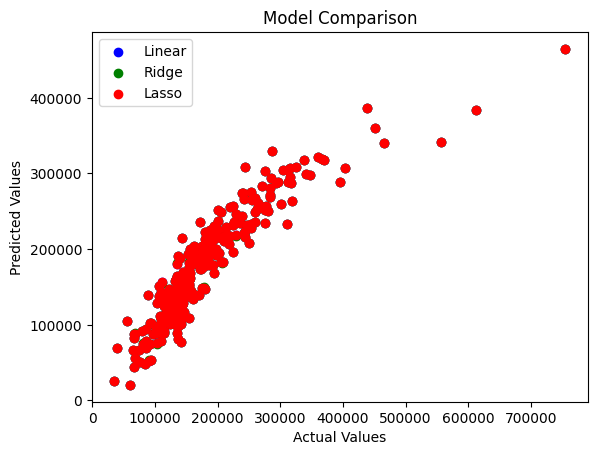

In [9]:
plt.scatter(y_test, y_pred_lr, color='blue', label='Linear')
plt.scatter(y_test, y_pred_ridge, color='green', label='Ridge')
plt.scatter(y_test, y_pred_lasso, color='red', label='Lasso')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Model Comparison")
plt.legend()
plt.show()

In [10]:
results = pd.DataFrame({
    "Actual": y_test,
    "Linear_Prediction": y_pred_lr,
    "Ridge_Prediction": y_pred_ridge,
    "Lasso_Prediction": y_pred_lasso
})

results.to_csv("predictions.csv", index=False)

print("\nPredictions saved to predictions.csv")


Predictions saved to predictions.csv
